Goal: Compare model performance under different hold‑out sizes and seeds. You’ll:

Use 70/30 and 80/20 splits (with/without stratification),

Repeat over many random seeds to estimate variability,

Summarize metrics (Accuracy, ROC‑AUC) with mean ± std,

Visualize distributions and inspect calibration & confusion matrices for one seed.

We’ll use scikit‑learn’s Breast Cancer dataset (binary).

In [1]:
# pip install scikit-learn matplotlib seaborn numpy
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
data = load_breast_cancer()
X, y = data.data, (data.target==0).astype(int)   # 1 = malignant (positive)


2) Helper: evaluate one split

In [3]:
def eval_once(test_size=0.2, seed=42, stratify=True):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=test_size, random_state=seed,
        stratify=y if stratify else None
    )
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000))
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    proba = clf.predict_proba(Xte)[:,1]
    acc = accuracy_score(yte, yhat)
    auc = roc_auc_score(yte, proba)
    return acc, auc, clf, (Xte, yte, yhat, proba)

3) Compare 70/30 vs 80/20 across seeds

In [4]:
seeds = list(range(30))  # 30 repeats
results = []
for split, ts in [('70/30', 0.30), ('80/20', 0.20)]:
    accs, aucs = [], []
    for s in seeds:
        acc, auc, _, _ = eval_once(test_size=ts, seed=s, stratify=True)
        accs.append(acc); aucs.append(auc)
    results.append((split, np.mean(accs), np.std(accs), np.mean(aucs), np.std(aucs)))

import pandas as pd
summary = pd.DataFrame(results, columns=['split','acc_mean','acc_std','auc_mean','auc_std'])
summary

,split,acc_mean,acc_std,auc_mean,auc_std
0,70/30,0.975439,0.010285,0.995045,0.003943
1,80/20,0.973977,0.012909,0.994731,0.005153


Interpretation tip: Smaller test sets (80/20) often show higher variance in test metrics (fewer samples), while larger test sets (70/30) reduce variance but give less data to train on—trade‑off depends on dataset size/complexity.

4) Visualize score distributions

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_5224\2466585496.py:17: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


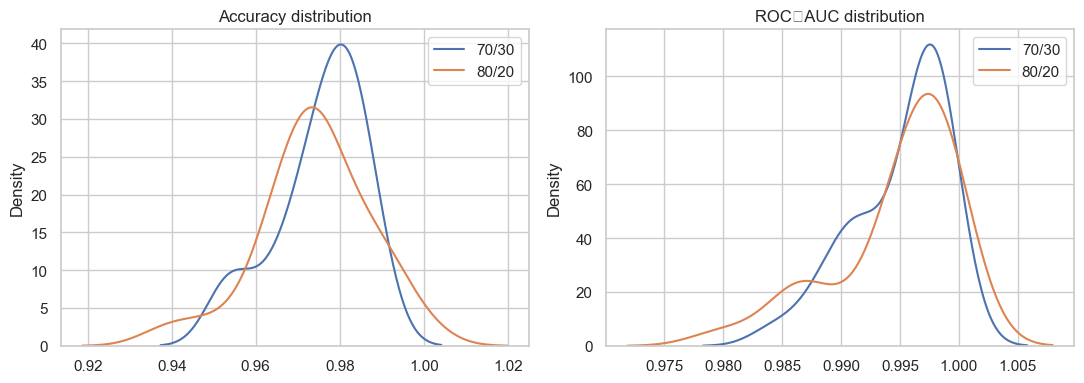

In [5]:
def collect_scores(ts):
    accs, aucs = [], []
    for s in seeds:
        a, u, _, _ = eval_once(test_size=ts, seed=s, stratify=True)
        accs.append(a); aucs.append(u)
    return np.array(accs), np.array(aucs)

acc70, auc70 = collect_scores(0.30)
acc80, auc80 = collect_scores(0.20)

fig, axes = plt.subplots(1,2, figsize=(11,4))
sns.kdeplot(acc70, ax=axes[0], label='70/30'); sns.kdeplot(acc80, ax=axes[0], label='80/20')
axes[0].set_title('Accuracy distribution'); axes[0].legend()

sns.kdeplot(auc70, ax=axes[1], label='70/30'); sns.kdeplot(auc80, ax=axes[1], label='80/20')
axes[1].set_title('ROC‑AUC distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

5) One seed deep‑dive: confusion matrix & curves

80/20, seed=7 → Acc=0.974, ROC‑AUC=0.995


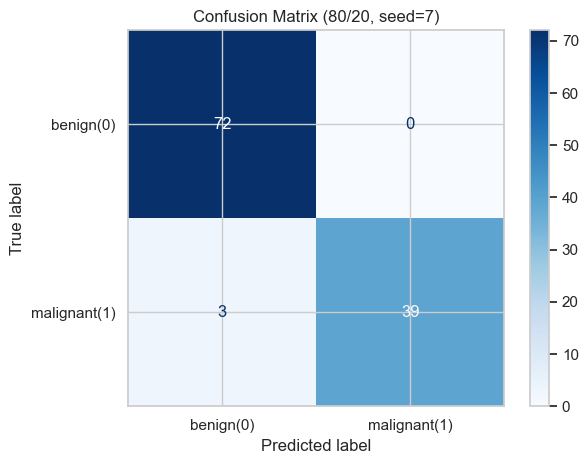

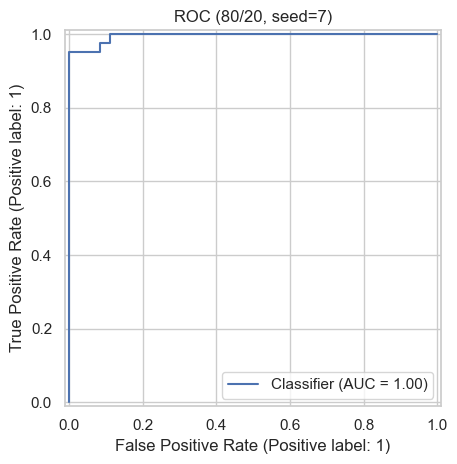

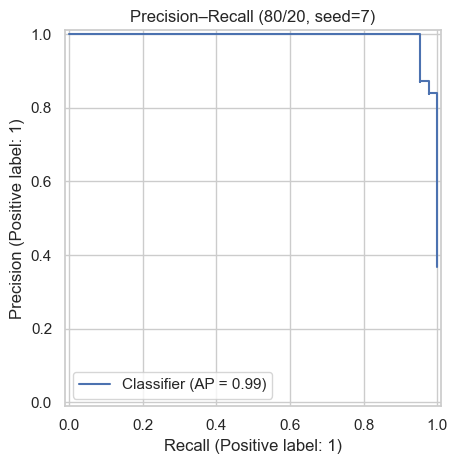

In [6]:
acc, auc, clf, (Xte, yte, yhat, proba) = eval_once(test_size=0.20, seed=7, stratify=True)
print(f"80/20, seed=7 → Acc={acc:.3f}, ROC‑AUC={auc:.3f}")

ConfusionMatrixDisplay(confusion_matrix(yte, yhat), display_labels=['benign(0)','malignant(1)']).plot(cmap='Blues')
plt.title('Confusion Matrix (80/20, seed=7)'); plt.tight_layout(); plt.show()

RocCurveDisplay.from_predictions(yte, proba)
plt.title('ROC (80/20, seed=7)'); plt.tight_layout(); plt.show()

PrecisionRecallDisplay.from_predictions(yte, proba)
plt.title('Precision–Recall (80/20, seed=7)'); plt.tight_layout(); plt.show()

6) (Optional) Stratified vs non‑stratified impact

In [7]:
def compare_stratify(ts=0.2):
    acc_s, auc_s, acc_ns, auc_ns = [], [], [], []
    for s in seeds:
        a1, u1, _, _ = eval_once(test_size=ts, seed=s, stratify=True)
        a2, u2, _, _ = eval_once(test_size=ts, seed=s, stratify=False)
        acc_s.append(a1); auc_s.append(u1); acc_ns.append(a2); auc_ns.append(u2)
    return (np.mean(acc_s), np.std(acc_s), np.mean(auc_s), np.std(auc_s)), \
           (np.mean(acc_ns), np.std(acc_ns), np.mean(auc_ns), np.std(auc_ns))

strat, nostrat = compare_stratify(0.20)
print("80/20 stratified   Acc mean±std, AUC mean±std:", strat)
print("80/20 non‑strat    Acc mean±std, AUC mean±std:", nostrat)

80/20 stratified   Acc mean±std, AUC mean±std: (np.float64(0.9739766081871345), np.float64(0.01290861991499655), np.float64(0.994731040564374), np.float64(0.005153451526868118))
80/20 non‑strat    Acc mean±std, AUC mean±std: (np.float64(0.9760233918128652), np.float64(0.011754240492539045), np.float64(0.9952374462916788), np.float64(0.004297402485926224))


Expectation: Stratification stabilizes metrics (preserves class balance in both splits).

7) (Optional) Bootstrap the test metric for CI

In [8]:
def bootstrap_ci(y_true, y_prob, func, B=2000, alpha=0.05):
    rng = np.random.default_rng(0)
    stats = []
    n = len(y_true)
    for _ in range(B):
        idx = rng.integers(0, n, n)
        stats.append(func(y_true[idx], y_prob[idx]))
    lo, hi = np.quantile(stats, [alpha/2, 1-alpha/2])
    return lo, hi

# Example: 80/20, seed=7 ROC-AUC CI
from sklearn.metrics import roc_auc_score
lo, hi = bootstrap_ci(yte, proba, roc_auc_score, B=1000)
print(f"ROC‑AUC 95% bootstrap CI: [{lo:.3f}, {hi:.3f}]")

ROC‑AUC 95% bootstrap CI: [0.986, 1.000]


Repeat the experiment with DecisionTreeClassifier(max_depth=4) and compare the variance of metrics vs Logistic Regression for both 70/30 and 80/20. Which model is more sensitive to the split?

In [9]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def run_experiment(X, y, n_repeats=30):
    """
    Runs repeated experiments to calculate metric variance.
    """
    
    # Configuration
    split_ratios = {
        '70/30': 0.30, # test_size
        '80/20': 0.20  # test_size
    }
    
    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'Decision Tree (depth=4)': DecisionTreeClassifier(max_depth=4, random_state=42)
    }
    
    results = []

    print(f"Running experiment with {n_repeats} iterations per configuration...\n")

    for split_name, test_size in split_ratios.items():
        for model_name, model in models.items():
            scores = []
            
            # Repeat the split n times to measure variance
            for i in range(n_repeats):
                # Random state is i to ensure different splits every time, 
                # but reproducible across models
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=test_size, random_state=i
                )
                
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                scores.append(accuracy_score(y_test, preds))
            
            # Calculate metrics
            mean_score = np.mean(scores)
            std_dev = np.std(scores)
            variance = np.var(scores)
            
            results.append({
                'Split Ratio': split_name,
                'Model': model_name,
                'Mean Accuracy': mean_score,
                'Std Dev': std_dev,
                'Variance': variance
            })

    return pd.DataFrame(results)

# --- Main Execution ---

# 1. Load Data (Replace this with your file loading logic)
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Run Experiment
df_results = run_experiment(X, y)

# 3. Display Results
print("--- Experiment Results ---")
print(df_results[['Split Ratio', 'Model', 'Mean Accuracy', 'Variance']].to_string(index=False))

# 4. Analyze Sensitivity
print("\n--- Sensitivity Analysis ---")
# Group by model to see average variance across all splits
avg_variance = df_results.groupby('Model')['Variance'].mean()
most_sensitive = avg_variance.idxmax()
least_sensitive = avg_variance.idxmin()

print(f"Average Variance by Model:\n{avg_variance}\n")
print(f"Conclusion: The {most_sensitive} is more sensitive to the data split (higher variance).")
print(f"The {least_sensitive} is more stable (lower variance).")


Running experiment with 30 iterations per configuration...



C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stab

--- Experiment Results ---
Split Ratio                   Model  Mean Accuracy  Variance
      70/30     Logistic Regression       0.945614  0.000176
      70/30 Decision Tree (depth=4)       0.931579  0.000349
      80/20     Logistic Regression       0.944444  0.000274
      80/20 Decision Tree (depth=4)       0.931579  0.000536

--- Sensitivity Analysis ---
Average Variance by Model:
Model
Decision Tree (depth=4)    0.000442
Logistic Regression        0.000225
Name: Variance, dtype: float64

Conclusion: The Decision Tree (depth=4) is more sensitive to the data split (higher variance).
The Logistic Regression is more stable (lower variance).


Add a 60/40 split; update the summary table and discuss the trade‑offs you see across 60/40, 70/30, 80/20 (bias/variance, training size, test reliability).

In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def run_extended_experiment(X, y, n_repeats=30):
    """
    Runs repeated experiments for 60/40, 70/30, and 80/20 splits.
    """
    
    # Updated split ratios to include 60/40
    split_ratios = {
        '60/40': 0.40, # test_size
        '70/30': 0.30, # test_size
        '80/20': 0.20  # test_size
    }
    
    models = {
        'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
        'Decision Tree (depth=4)': DecisionTreeClassifier(max_depth=4, random_state=42)
    }
    
    results = []

    print(f"Running experiment with {n_repeats} iterations per configuration...\n")

    for split_name, test_size in split_ratios.items():
        for model_name, model in models.items():
            scores = []
            
            # Monte Carlo Cross-Validation (Repeated Random Sub-sampling)
            for i in range(n_repeats):
                # Random state 'i' ensures different splits each iteration
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=test_size, random_state=i
                )
                
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                scores.append(accuracy_score(y_test, preds))
            
            # Calculate aggregate metrics
            results.append({
                'Split Ratio': split_name,
                'Model': model_name,
                'Mean Accuracy': np.mean(scores),
                'Variance': np.var(scores),
                'Std Dev': np.std(scores)
            })

    return pd.DataFrame(results)

# --- Main Execution ---

# 1. Load Data (Using Breast Cancer dataset as a proxy for your file)
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Run Experiment
df_results = run_extended_experiment(X, y)

# 3. Display Summary Table
print("--- Updated Summary Table ---")
# Formatting for cleaner output
pd.set_option('display.float_format', '{:.5f}'.format)
print(df_results[['Split Ratio', 'Model', 'Mean Accuracy', 'Variance']])


Running experiment with 30 iterations per configuration...



C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stab

--- Updated Summary Table ---
  Split Ratio                    Model  Mean Accuracy  Variance
0       60/40      Logistic Regression        0.94664   0.00021
1       60/40  Decision Tree (depth=4)        0.92515   0.00033
2       70/30      Logistic Regression        0.94581   0.00018
3       70/30  Decision Tree (depth=4)        0.93158   0.00035
4       80/20      Logistic Regression        0.94474   0.00029
5       80/20  Decision Tree (depth=4)        0.93158   0.00054


For the 80/20 split, run 10 different seeds and compute the mean ± std of Recall for the positive class (malignant). How variable is recall?

In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score

def analyze_recall_variability():
    # 1. Load Data
    data = load_breast_cancer()
    X = data.data
    y = data.target
    
    # Note: In this dataset, 0 = 'malignant', 1 = 'benign'.
    # We want recall for 'malignant', so we set pos_label=0.
    target_class_label = 0 
    target_class_name = data.target_names[target_class_label]
    
    # 2. Configuration
    n_seeds = 10
    test_size = 0.20
    
    models = {
        'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
        'Decision Tree (depth=4)': DecisionTreeClassifier(max_depth=4, random_state=42)
    }
    
    results = {name: [] for name in models}
    
    print(f"Calculating Recall for class '{target_class_name}' (label {target_class_label})")
    print(f"Split: 80/20 | Iterations: {n_seeds}\n")

    # 3. Run Experiment
    for i in range(n_seeds):
        # Use 'i' as the random_state for the split to get 10 different folds
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=i, stratify=y
        )
        
        for name, model in models.items():
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            
            # Calculate Recall specifically for the Malignant class
            rec = recall_score(y_test, preds, pos_label=target_class_label)
            results[name].append(rec)

    # 4. Compute Statistics and Display
    summary_data = []
    for name, scores in results.items():
        mean_score = np.mean(scores)
        std_score = np.std(scores)
        summary_data.append({
            'Model': name,
            'Mean Recall': mean_score,
            'Std Dev': std_score,
            'Min': np.min(scores),
            'Max': np.max(scores),
            'Formatted': f"{mean_score:.4f} ± {std_score:.4f}"
        })
    
    df = pd.DataFrame(summary_data)
    print(df[['Model', 'Formatted', 'Min', 'Max']].to_string(index=False))
    
    return df

# Run the analysis
df_recall = analyze_recall_variability()


Calculating Recall for class 'malignant' (label 0)
Split: 80/20 | Iterations: 10



C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                  Model       Formatted     Min     Max
    Logistic Regression 0.9500 ± 0.0198 0.90476 0.97619
Decision Tree (depth=4) 0.9214 ± 0.0564 0.78571 1.00000


C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Use StratifiedKFold (5‑fold) cross‑validation and compare its mean ROC‑AUC with the single split results. When would you prefer CV over a single hold‑out?

In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

def compare_cv_vs_holdout():
    # 1. Load Data
    data = load_breast_cancer()
    X = data.data
    y = data.target
    
    # 2. Configuration
    models = {
        'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
        'Decision Tree (depth=4)': DecisionTreeClassifier(max_depth=4, random_state=42)
    }
    
    results = []
    
    print("Running comparison: Single Split (80/20) vs Stratified K-Fold (5-fold)...\n")
    
    for name, model in models.items():
        # --- A. Single Hold-out Split (80/20) ---
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.20, random_state=42, stratify=y
        )
        
        model.fit(X_train, y_train)
        # ROC-AUC requires probabilities of the positive class
        y_probs = model.predict_proba(X_test)[:, 1]
        single_split_auc = roc_auc_score(y_test, y_probs)
        
        # --- B. Stratified K-Fold Cross-Validation (5-fold) ---
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # cross_val_score handles the splitting, fitting, and scoring
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
        mean_cv_auc = np.mean(cv_scores)
        std_cv_auc = np.std(cv_scores)
        
        results.append({
            'Model': name,
            'Single Split AUC': single_split_auc,
            'CV Mean AUC': mean_cv_auc,
            'CV Std Dev': std_cv_auc,
            'Difference': mean_cv_auc - single_split_auc
        })
        
    # 3. Display Results
    df = pd.DataFrame(results)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(df[['Model', 'Single Split AUC', 'CV Mean AUC', 'CV Std Dev']].to_string(index=False))

compare_cv_vs_holdout()


Running comparison: Single Split (80/20) vs Stratified K-Fold (5-fold)...



C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stab

                  Model  Single Split AUC  CV Mean AUC  CV Std Dev
    Logistic Regression            0.9954       0.9917      0.0048
Decision Tree (depth=4)            0.9342       0.9152      0.0367
